In [43]:
from __future__ import annotations
import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable, Iterable, Sequence, Mapping

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean

from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.colors import BoundaryNorm, ListedColormap, LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FixedLocator
import cartopy.mpl.ticker as cticker
import matplotlib.ticker as mticker

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    
from DataUtil import (
    build_experiments,
    DEFAULT_EXPERIMENTS
)

from ObsUtil import (
    OBS_REGISTRY,
    get_obs_file,
    list_obs_sources,
    obs_coverage,
)

from time_window import(
    build_windows_from_start
)


In [83]:
@dataclass(frozen=True)
class TccWindowMapPlotConfig:
    # where files live (e.g., diag_output/tcc_rmse_base/Jan2012)
    input_dir: Path

    # filename tokens
    prefix: str = "s2s_base_tcc_rmse"
    group: str = "Jan2012"
    freq: str = "daily"
    run: str = "fc"
    obs: str = "ERA5"
    period: str = "201201-201203"
    region: str = "ALL"  # keep as ALL unless your map files use something else

    # experiments
    exp_order: tuple[str, ...] = ()

    # ensemble settings (allow per-exp nens)
    nens: int | dict[str, int] = 40
    ens_start: int = 1
    ens_prefix: str = "EN"
    ens_width: int = 2
    include_ensmean: bool = True
    ensmean_tag: str = "ENSMEAN"
    compute_ensmean_if_missing: bool = False

    # window settings (file has 'window' dim as string labels; default labels below)
    lead_bins: dict[str, tuple[int, int]] = field(default_factory=dict)
    window_dim_candidates: tuple[str, ...] = ("window", "lead_bin", "lead_window", "bin")
    lead_day_candidates: tuple[str, ...] = ("lead_days", "lead_day", "lead")

    # variable names inside netcdf (handles ENSMEAN suffix too via _pick_metric_var)
    tcc_var_candidates: tuple[str, ...] = (
        "TCC_ensmean",
        "ACC_ensmean",
        "CORR_ensmean",
        "TCC",
        "ACC",
        "CORR",
        "tcc",
        "acc",
        "corr",
    )
    rmse_var_candidates: tuple[str, ...] = (
        "RMSE_ensmean",
        "nRMSE_ensmean",
        "RMSE",
        "nRMSE",
        "rmse",
        "nrmse",
    )

    # NEW: bias candidates
    bias_var_candidates: tuple[str, ...] = (
        "BIAS_ensmean",
        "Bias_ensmean",
        "BIAS",
        "Bias",
        "bias",
    )

    # coordinate/dim names
    lat_candidates: tuple[str, ...] = ("lat", "latitude", "LAT")
    lon_candidates: tuple[str, ...] = ("lon", "longitude", "LON")

    # plot settings
    ncols: int = 4
    figsize_per_panel: tuple[float, float] = (3.6, 2.6)

    # colormap settings
    cmap: str = "viridis"
    vmin: float | None = None
    vmax: float | None = None

    # discrete styling (when var_levels is provided)
    discrete_trim: tuple[float, float] = (0.10, 0.95)  # match your example look
    discrete_extend: str = "both"  # "neither" | "min" | "max" | "both"

    add_colorbar: bool = True

    # cartopy aesthetics
    coast_resolution: str = "110m"
    coast_lw: float = 0.5
    grid_lw: float = 0.3
    grid_alpha: float = 0.35
    grid_ls: str = "--"
    label_fontsize: int = 12

    # --- land/ocean masking (optional) ---
    mask: Literal["land", "ocean", "none"] = "none"
    mask_file: Path | None = None
    mask_var: str = "landfrac"
    mask_threshold: float = 0.5
    mask_interp: str = "nearest"  # nearest keeps coastline crisp

    # display names for experiments (plotting only)
    exp_display: dict[str, str] = field(default_factory=dict)


class TccWindowMapPlotter:
    """
    Window metric 2D map plotter across experiments.

    Files:
      {prefix}_{group}_{freq}_{run}_{obs}_{period}_{region}_{exp}_{tag}_{var}.nc

    tag:
      - members: ENxx (from ens_start..ens_start+nens-1)
      - ensmean: ENSMEAN (cfg.ensmean_tag)

    NetCDF variables (your outputs):
      - members: TCC, RMSE, BIAS
      - ensmean: TCC_ensmean, RMSE_ensmean, BIAS_ensmean

    metric options:
      - 'TCC'/'ACC'/'CORR'
      - 'RMSE'/'NRMSE'
      1   - 'BIAS'/'Bias'
    """

    def __init__(self, cfg: TccWindowMapPlotConfig):
        if not cfg.lead_bins:
            object.__setattr__(
                cfg,
                "lead_bins",
                {
                    "week1-2": (1, 14),
                    "week3-4": (15, 28),
                    "week5-6": (29, 42),
                    "week7-8": (43, 56),
                },
            )
        self.cfg = cfg

    # ---------- masking ----------
    def _load_mask(self) -> xr.DataArray | None:
        if self.cfg.mask in ("none", None):
            return None
        if self.cfg.mask_file is None:
            raise ValueError("cfg.mask_file must be set when cfg.mask is 'land' or 'ocean'.")

        if getattr(self, "_mask_cache", None) is not None:
            return self._mask_cache

        ds = xr.open_dataset(self.cfg.mask_file)
        if self.cfg.mask_var not in ds.data_vars:
            raise KeyError(
                f"mask_var='{self.cfg.mask_var}' not found in {self.cfg.mask_file}. "
                f"Available: {list(ds.data_vars)}"
            )

        m = ds[self.cfg.mask_var].squeeze(drop=True)

        latn = next((n for n in self.cfg.lat_candidates if (n in m.dims or n in m.coords)), None)
        lonn = next((n for n in self.cfg.lon_candidates if (n in m.dims or n in m.coords)), None)
        if latn is None or lonn is None:
            raise ValueError(f"Mask does not look like lat-lon. dims={m.dims}, coords={list(m.coords)}")

        if (latn in m.dims) and (lonn in m.dims):
            m = m.transpose(latn, lonn)

        m = self._normalize_lon_if_needed(m)

        self._mask_cache = m
        return m

    def _apply_mask(self, da: xr.DataArray) -> xr.DataArray:
        if self.cfg.mask in ("none", None):
            return da

        m = self._load_mask()
        if m is None:
            return da

        latn, lonn = da.dims[0], da.dims[1]

        mi = m.interp(
            {m.dims[0]: da[latn], m.dims[1]: da[lonn]},
            method=self.cfg.mask_interp,
        )

        is_land = mi >= float(self.cfg.mask_threshold)

        if self.cfg.mask == "land":
            return da.where(is_land)
        if self.cfg.mask == "ocean":
            return da.where(~is_land)

        raise ValueError(f"Unknown cfg.mask={self.cfg.mask}. Use 'land', 'ocean', or 'none'.")

    # ---------- tag helpers ----------
    def _ens_tag(self, k: int) -> str:
        return f"{self.cfg.ens_prefix}{k:0{self.cfg.ens_width}d}"

    def _get_nens_for_exp(self, exp: str) -> int:
        nens = self.cfg.nens
        if isinstance(nens, dict):
            if exp not in nens:
                raise KeyError(f"Missing nens for exp={exp}. Provided keys: {list(nens)}")
            return int(nens[exp])
        return int(nens)

    # ---------- file collection ----------
    def collect_member_and_ensmean_files(self, *, exp: str, var: str, strict: bool = False):
        nens = self._get_nens_for_exp(exp)

        member_files: list[Path] = []
        member_ens: list[int] = []

        for k in range(self.cfg.ens_start, self.cfg.ens_start + nens):
            tag = self._ens_tag(k)
            f = self.cfg.input_dir / (
                f"{self.cfg.prefix}_{self.cfg.group}_{self.cfg.freq}_{self.cfg.run}_"
                f"{self.cfg.obs}_{self.cfg.period}_{self.cfg.region}_{exp}_{tag}_{var}.nc"
            )
            if f.exists():
                member_files.append(f)
                member_ens.append(k)

        ensmean_file: Path | None = None
        if self.cfg.include_ensmean:
            tag = self.cfg.ensmean_tag
            f = self.cfg.input_dir / (
                f"{self.cfg.prefix}_{self.cfg.group}_{self.cfg.freq}_{self.cfg.run}_"
                f"{self.cfg.obs}_{self.cfg.period}_{self.cfg.region}_{exp}_{tag}_{var}.nc"
            )
            if f.exists():
                ensmean_file = f

        if strict and (not member_files) and (ensmean_file is None):
            raise FileNotFoundError(
                f"No files found for exp={exp} var={var} in {self.cfg.input_dir}\n"
                f"pattern: {self.cfg.prefix}_{self.cfg.group}_{self.cfg.freq}_{self.cfg.run}_"
                f"{self.cfg.obs}_{self.cfg.period}_{self.cfg.region}_{exp}_<TAG>_{var}.nc"
            )

        return member_files, member_ens, ensmean_file

    # ---------- colormap helpers ----------
    def _get_cmap_bias(self, *, var_levels: Iterable[float] | None):
        if var_levels is None:
            from matplotlib.colors import TwoSlopeNorm

            cmap = plt.get_cmap(self.cfg.cmap)
            vmin = self.cfg.vmin if self.cfg.vmin is not None else -5
            vmax = self.cfg.vmax if self.cfg.vmax is not None else 5
            norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
            return cmap, norm, None, "neither"

        levels = np.asarray(list(var_levels), dtype=float)
        if levels.ndim != 1 or levels.size < 3:
            raise ValueError("BIAS levels must be a 1D sequence with at least 3 values.")
        if not np.all(np.diff(levels) > 0):
            raise ValueError(f"BIAS levels must be strictly increasing. Got {levels}")
        if not (levels[0] < 0 < levels[-1]):
            raise ValueError("BIAS levels must straddle zero (include negative and positive).")

        base = plt.get_cmap(self.cfg.cmap)

        nbins = levels.size - 1
        neg_bins = int(np.sum(levels[:-1] < 0))
        pos_bins = nbins - neg_bins
        # allocate colors from low-end and high-end of base cmap
        neg_cols = base(np.linspace(0.0, 0.45, max(neg_bins, 1)))
        pos_cols = base(np.linspace(0.55, 1.0, max(pos_bins, 1)))
        colors = np.vstack([neg_cols[:neg_bins], pos_cols[:pos_bins]])

        cmap = ListedColormap(colors)
        norm = BoundaryNorm(levels, cmap.N, clip=False)
        extend = self.cfg.discrete_extend or "both"
        return cmap, norm, levels, extend

    def _pick_metric_var(self, ds: xr.Dataset, metric: str) -> str:
        mu = metric.upper()

        if mu == "ACC":
            mu = "TCC"
        if mu == "CORRELATION":
            mu = "TCC"
        if mu == "BIAS":
            mu = "BIAS"

        if mu in ("TCC", "CORR"):
            for n in self.cfg.tcc_var_candidates:
                if n in ds.data_vars:
                    return n
            for n in ds.data_vars:
                nu = n.upper()
                if nu.startswith(("TCC", "ACC", "CORR")):
                    return n
            raise KeyError(f"No TCC/ACC/CORR variable found. data_vars={list(ds.data_vars)}")

        if mu in ("RMSE", "NRMSE"):
            for n in self.cfg.rmse_var_candidates:
                if n in ds.data_vars:
                    return n
            for n in ds.data_vars:
                nu = n.upper()
                if nu.startswith(("RMSE", "NRMSE")):
                    return n
            raise KeyError(f"No RMSE/NRMSE variable found. data_vars={list(ds.data_vars)}")

        if mu in ("BIAS",):
            for n in self.cfg.bias_var_candidates:
                if n in ds.data_vars:
                    return n
            for n in ds.data_vars:
                nu = n.upper()
                if nu.startswith("BIAS"):
                    return n
            raise KeyError(f"No BIAS variable found. data_vars={list(ds.data_vars)}")

        raise ValueError(f"Unknown metric={metric}. Use 'TCC'/'ACC' or 'RMSE'/'NRMSE' or 'BIAS'.")

    def _select_window(self, da: xr.DataArray, window_sel) -> xr.DataArray:
        for wdim in self.cfg.window_dim_candidates:
            if wdim not in da.dims:
                continue

            if window_sel is None:
                return da.isel({wdim: 0})
            if isinstance(window_sel, int):
                return da.isel({wdim: window_sel})

            if isinstance(window_sel, str):
                try:
                    return da.sel({wdim: window_sel})
                except Exception:
                    if window_sel in self.cfg.lead_bins:
                        start, end = self.cfg.lead_bins[window_sel]
                        if ("window_start" in da.coords) and ("window_end" in da.coords):
                            ws = np.asarray(da["window_start"].values)
                            we = np.asarray(da["window_end"].values)
                            idx = np.where((ws == start) & (we == end))[0]
                            if idx.size == 0:
                                raise KeyError(
                                    f"No window matched label={window_sel} -> (start,end)=({start},{end}). "
                                    f"Available starts={ws}, ends={we}"
                                )
                            return da.isel({wdim: int(idx[0])})
                        return da.sel({wdim: window_sel})
                    raise

            if isinstance(window_sel, tuple) and len(window_sel) == 2:
                start, end = window_sel
                if ("window_start" in da.coords) and ("window_end" in da.coords):
                    ws = np.asarray(da["window_start"].values)
                    we = np.asarray(da["window_end"].values)
                    idx = np.where((ws == start) & (we == end))[0]
                    if idx.size == 0:
                        raise KeyError(
                            f"No window matched window_start={start}, window_end={end}. "
                            f"Available starts={ws}, ends={we}"
                        )
                    return da.isel({wdim: int(idx[0])})
                return da.sel({wdim: window_sel})

            return da.sel({wdim: window_sel})

        if isinstance(window_sel, tuple) and len(window_sel) == 2:
            start, end = window_sel
            for ldn in self.cfg.lead_day_candidates:
                if ldn in da.coords:
                    sub = da.sel({ldn: slice(start, end)})
                    if ldn in sub.dims:
                        return sub.mean(ldn)
                    return sub

        return da

    def _open_metric_ensmean_2d(self, *, exp: str, var: str, metric: str, window_sel=None) -> xr.DataArray:
        member_files, _, ensmean_file = self.collect_member_and_ensmean_files(exp=exp, var=var, strict=True)

        if ensmean_file is None and not self.cfg.compute_ensmean_if_missing:
            raise FileNotFoundError(
                f"ENSMEAN file missing for exp={exp} var={var} and compute_ensmean_if_missing=False.\n"
                f"Found {len(member_files)} member files."
            )

        if ensmean_file is not None:
            ds = xr.open_dataset(ensmean_file)
        else:
            dss = [xr.open_dataset(f) for f in member_files]
            ds = xr.concat(dss, dim="ens").mean("ens", skipna=True)

        vname = self._pick_metric_var(ds, metric)
        da = ds[vname].squeeze(drop=True)

        if "region" in da.dims:
            da = da.isel(region=0)

        da = self._select_window(da, window_sel).squeeze(drop=True)

        latn = next((n for n in self.cfg.lat_candidates if n in da.dims), None)
        lonn = next((n for n in self.cfg.lon_candidates if n in da.dims), None)
        if latn is None or lonn is None:
            raise ValueError(
                f"exp={exp} var={var}: output is NOT a 2D lat-lon map.\n"
                f"dims={da.dims}\n"
                f"This likely points to region-aggregated files (region={self.cfg.region}) rather than map files."
            )
        return da.transpose(latn, lonn)

    def _order_exps(self, exps: list[str]) -> list[str]:
        if self.cfg.exp_order:
            ordered = [e for e in self.cfg.exp_order if e in exps]
            rest = sorted([e for e in exps if e not in set(ordered)])
            return ordered + rest
        return sorted(exps)

    def _normalize_lon_if_needed(self, da: xr.DataArray) -> xr.DataArray:
        lon_name = da.dims[1]
        lon = np.asarray(da[lon_name].values)
        lon_min = float(np.nanmin(lon))
        lon_max = float(np.nanmax(lon))

        if lon_min < 0 and lon_max <= 180:
            return da

        if lon_min >= 0 and lon_max > 180:
            lon_new = ((lon + 180) % 360) - 180
            return da.assign_coords({lon_name: lon_new}).sortby(lon_name)

        return da

    def _get_cmap_and_norm(self, *, var_levels: Iterable[float] | None):
        if var_levels is None:
            return plt.get_cmap(self.cfg.cmap), None, None, "neither"

        levels = np.asarray(list(var_levels), dtype=float)
        if levels.ndim != 1 or levels.size < 3:
            raise ValueError("var_levels must be a 1D sequence with at least 3 values.")
        if not np.all(np.diff(levels) > 0):
            raise ValueError(f"var_levels must be strictly increasing. Got {levels}")

        base = plt.get_cmap(self.cfg.cmap)
        lo, hi = self.cfg.discrete_trim
        nbins = levels.size - 1

        colors = np.vstack([
            np.array([[1.0, 1.0, 1.0, 1.0]]),  # WHITE for values < levels[1]
            base(np.linspace(lo, hi, nbins - 1)),
        ])

        cmap = ListedColormap(colors)
        cmap.set_under("white")
        cmap.set_over(colors[-1])

        norm = BoundaryNorm(levels, cmap.N, clip=False)
        extend = self.cfg.discrete_extend if self.cfg.discrete_extend else "both"
        return cmap, norm, levels, extend

    def _get_cmap_discrete(self, *, var_levels: Iterable[float] | None):
        if var_levels is None:
            return plt.get_cmap(self.cfg.cmap), None, None, "neither"

        levels = np.asarray(list(var_levels), dtype=float)
        if levels.ndim != 1 or levels.size < 3:
            raise ValueError("var_levels must be a 1D sequence with at least 3 values.")
        if not np.all(np.diff(levels) > 0):
            raise ValueError(f"var_levels must be strictly increasing. Got {levels}")

        base = plt.get_cmap(self.cfg.cmap)
        lo, hi = self.cfg.discrete_trim
        nbins = levels.size - 1
        colors = base(np.linspace(lo, hi, nbins))

        cmap = ListedColormap(colors)
        norm = BoundaryNorm(levels, cmap.N, clip=False)
        extend = self.cfg.discrete_extend or "both"
        return cmap, norm, levels, extend

    # ----------------------------
    # Public plotting
    # ----------------------------
    def plot_var_panel_exps_x_windows(
        self,
        *,
        var: str,
        unit: str, 
        exps: list[str] | tuple[str, ...],
        windows: list[str | tuple[int, int] | int] | tuple[str | tuple[int, int] | int, ...] = (
            "week1-2",
            "week3-4",
            "week5-6",
            "week7-8",
        ),
        metric: str = "TCC",
        baseline_exp: str | None = None,
        var_levels: Iterable[float] | None = None,
        out_png: Path | None = None,
        suptitle: str | None = None,
        show: bool = True,
        figsize: tuple | None = (8, 6),
        fontz: float = 12,
        panel_idx: int = 1, 
        dpi: int = 600,
    ):
        mu = metric.upper()
        if mu == "ACC":
            mu = "TCC"
        if mu == "BIAS":
            mu = "BIAS"

        exps_ordered = self._order_exps(list(exps))
        windows_list = list(windows)

        if mu in ("TCC", "CORR"):
            cmap, norm, levels, extend = self._get_cmap_and_norm(var_levels=var_levels)
        elif mu in ("RMSE", "NRMSE"):
            cmap, norm, levels, extend = self._get_cmap_discrete(var_levels=var_levels)
        elif mu == "BIAS":
            cmap, norm, levels, extend = self._get_cmap_bias(var_levels=var_levels)
        else:
            raise ValueError(f"Unknown metric={metric}")

        maps: dict[tuple[str, int], xr.DataArray] = {}
        for exp in exps_ordered:
            for wi, w in enumerate(windows_list):
                da = self._open_metric_ensmean_2d(exp=exp, var=var, metric=mu, window_sel=w)
                da = self._normalize_lon_if_needed(da)
                da = self._apply_mask(da)
                maps[(exp, wi)] = da

        if baseline_exp is not None:
            if mu not in ("RMSE", "NRMSE", "BIAS"):
                raise ValueError("baseline_exp differencing is only enabled for RMSE/NRMSE/BIAS (not TCC).")
            if baseline_exp not in exps_ordered:
                raise KeyError(f"baseline_exp={baseline_exp} not in exps: {exps_ordered}")
            for wi in range(len(windows_list)):
                base = maps[(baseline_exp, wi)]
                for exp in exps_ordered:
                    maps[(exp, wi)] = maps[(exp, wi)] - base

        nrows = len(exps_ordered)
        ncols = len(windows_list)

        if figsize is None:
            fw = self.cfg.figsize_per_panel[0] * ncols
            fh = self.cfg.figsize_per_panel[1] * nrows
            figsize = (fw, fh)

        if HAS_CARTOPY:
            proj = ccrs.PlateCarree()
            fig, axes = plt.subplots(
                nrows,
                ncols,
                figsize=figsize,
                constrained_layout=False,
                subplot_kw=dict(projection=proj),
            )
            lon_formatter = LongitudeFormatter(zero_direction_label=True, dateline_direction_label=True)
            lat_formatter = LatitudeFormatter()
        else:
            fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=False)

        axes = np.array(axes).reshape(nrows, ncols)

        extent = (-180, 180, -90, 90)
        lon_ticks = np.arange(-180, 181, 90)
        lat_ticks = np.arange(-90, 91, 30)

        im = None
        for r, exp in enumerate(exps_ordered):
            # robust exp_display mapping: handles "GROUP:EXP"
            s = str(exp).strip()
            key = s.split(":", 1)[-1].strip()
            exp_label = self.cfg.exp_display.get(key, key)

            for c, w in enumerate(windows_list):
                ax = axes[r, c]
                da = maps[(exp, c)]

                lat = da[da.dims[0]].values
                lon = da[da.dims[1]].values
                Z = da.values

                # window label
                if isinstance(w, str) and (w in self.cfg.lead_bins):
                    sday, eday = self.cfg.lead_bins[w]
                    w_pretty = w.replace("week", "Week ").replace("-", "–")
                    wlab = f"{w_pretty} (days {sday}–{eday})"
                else:
                    wlab = str(w)

                if HAS_CARTOPY:
                    ax.set_extent(extent, crs=ccrs.PlateCarree())
                    im = ax.pcolormesh(
                        lon,
                        lat,
                        Z,
                        transform=ccrs.PlateCarree(),
                        cmap=cmap,
                        norm=norm,
                        vmin=None if norm is not None else self.cfg.vmin,
                        vmax=None if norm is not None else self.cfg.vmax,
                    )
                    ax.coastlines(resolution=self.cfg.coast_resolution, linewidth=self.cfg.coast_lw)
                    
                    gl = ax.gridlines(
                        crs=ccrs.PlateCarree(),
                        draw_labels=True,
                        linewidth=self.cfg.grid_lw,
                        color="gray",
                        alpha=self.cfg.grid_alpha,
                        linestyle=self.cfg.grid_ls,
                        x_inline=False,
                        y_inline=False,
                    )
                    
                    gl.xlocator = FixedLocator(lon_ticks)
                    gl.ylocator = FixedLocator(lat_ticks)
                    gl.xformatter = lon_formatter
                    gl.yformatter = lat_formatter
                    
                    gl.top_labels = False
                    gl.right_labels = False
                    gl.bottom_labels = (r == nrows - 1)
                    gl.left_labels = (c in (0, 1))   # ← UPDATED
                    
                    gl.xpadding = 3
                    gl.ypadding = 3
                    gl.xlabel_style = {"size": fontz * 0.85}
                    gl.ylabel_style = {"size": fontz * 0.85}

                    # explicit ticks (for tick marks)
                    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
                    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
                    
                    # show tick marks but no tick labels (labels handled by gridliner)
                    ax.tick_params(
                        which="both",
                        direction="out",
                        length=4,
                        width=0.8,
                        labelbottom=False,
                        labelleft=False,
                    )

                else:
                    im = ax.pcolormesh(
                        lon,
                        lat,
                        Z,
                        cmap=cmap,
                        norm=norm,
                        vmin=None if norm is not None else self.cfg.vmin,
                        vmax=None if norm is not None else self.cfg.vmax,
                    )
                    ax.set_xlim(extent[0], extent[1])
                    ax.set_ylim(extent[2], extent[3])
                    ax.set_xticks(lon_ticks)
                    ax.set_yticks(lat_ticks)
                    if r != nrows - 1:
                        ax.tick_params(axis="x", labelbottom=False)
                    if c != 0:
                        ax.tick_params(axis="y", labelleft=False)

                # ---- CLEAN TITLES ----
                # experiment label only on first column
                panel_label = f"({chr(97 + panel_idx + r*len(windows_list) + c)})" 
                ax.set_title(f"{panel_label} {exp_label}", fontsize=fontz * 1.0, loc="left")
                # window label only on top row
                ax.set_title(f"{wlab}", fontsize=fontz * 1.0, loc="right")

        if suptitle is None:
            base_txt = f"{self.cfg.group} {var} {mu}"
            if baseline_exp is not None:
                bs = str(baseline_exp).strip()
                bkey = bs.split(":", 1)[-1].strip()
                base_txt += f" (minus {self.cfg.exp_display.get(bkey, bkey)})"
            suptitle = base_txt

        fig.suptitle(suptitle, fontsize=fontz * 1.0)

        fig.subplots_adjust(
            left=0.03,
            right=0.995,
            bottom=0.05,
            top=0.92,
            wspace=0.15,
            hspace=0.15,
        )

        # ---- FIGURE-LEVEL AXIS LABELS ----
        if self.cfg.add_colorbar and im is not None:
            if levels is None:
                cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.92, pad=0.02)
            else:
                cbar = fig.colorbar(
                    im,
                    ax=axes.ravel().tolist(),
                    boundaries=levels,
                    ticks=levels,
                    spacing="proportional",
                    shrink=0.55,
                    pad=0.01,
                    extend=extend,
                    extendfrac="auto",
                )
            cbar.set_label(f"{diag_var} {mu} ({unit})", fontsize=fontz * 0.90)

        if out_png is not None:
            out_png = Path(out_png)
            out_png.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out_png, dpi=dpi, bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close(fig)

        return fig


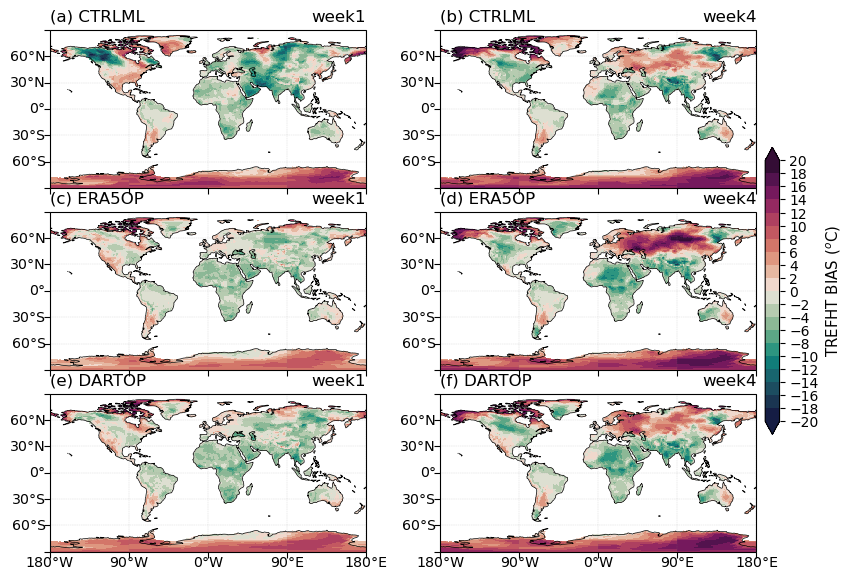

In [84]:
if __name__ == "__main__":
    data_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    diag_path = "/compyfs/zhan391/v3_dart_cda_scratch/diag_output/tcc_rmse_sigvar"
    land_mask = "/compyfs/zhan391/acme_init/lnd_sea_mask/landmask_1x1.nc"
    fig_path = "./"
    
    # landmask settings
    landmask_var = "landfrac"
    land_threshold = 0.5

    # config knobs
    ens_start = 1
    ens_prefix = "EN"
    ens_width = 2
    ensmean_tag = "ENSMEAN"
    include_ensmean = True
    compute_ensmean_if_missing = False

    exp_list = {
        "Jan2012": dict(
            models=["CTRL10-S0", "CAPT10-S0", "DART20-S0", "DART40-S0"],
            period="201201-201203",
            season="Winter",
            init_date="2012-01-01",
            init_month=1,
            run="fc",
            freq="daily",
        ),
        "Jun2012": dict(
            models=["CTRL10-S1", "CAPT10-S1", "DART40-S1"],
            period="201206-201208",
            season="Summer",
            init_date="2012-06-01",
            init_month=6,
            run="fc",
            freq="daily",
        ),
    }
    
    # obs -> {model_var -> obs_var}
    all_var_dict = {
        "ERA5": {
            "UBOT": "U10",
            "VBOT": "V10",
            "PRECT": "PRECT",
            "PSL": "PSL",
            "U850": "U850",
            "V850": "V850",
            "T850": "T850",
            "Q850": "Q850",
            "Z500": "Z500",
            "OMEGA500": "OMEGA500",
            "OMEGA200": "OMEGA200",
            "OMEGA850": "OMEGA850",
            "U200": "U200",
            "V200": "V200",
            "U500": "U500",
            "V500": "V500",
            "FLDS": "FLDS",
            "FLDSC": "FLDSC",
            "FLNS": "FLNS",
            "FLNSC": "FLNSC",
            "FSDS": "FSDS",
            "FSDSC": "FSDSC",
            "FSNS": "FSNS",
            "FSNSC": "FSNSC",
            "LHFLX": "LHFLX",
            "SHFLX": "SHFLX",
            "QFLX": "QFLX",
            "TREFHT": "TREFHT",
            "TS": "TS",
            "PRECSL": "PRECSL",
            "PRECC": "PRECC",
            "PRECL": "PRECL",
        },
        "GPCP": {"PRECT": "PRECT"},
        "GPM": {"PRECT": "PRECT"},
        "NOAA-OLR": {"FLUT": "FLUT"},
    }

    lead_bins = {
        "week1-2": (1, 14),
        #"week3-4": (15, 28),
        #"week5-6": (29, 42),
        "week7-8": (43, 56),
    }

    # choice on plot
    group = "Jan2012"
    obs = "ERA5"
    region = "ALL"
    prefix = "s2s_base_tcc_rmse"
    var_map = all_var_dict[obs]
    # obs_var = var_map.get(diag_var, diag_var)  # if you need it later
    

    # setup for figures
    diag_var = "TREFHT"
    metric = "BIAS"
    unit = r"$^{o}$C"
    vmin = -20
    vmax = 20
    var_levels = np.linspace(-20,20,21) #np.linspace(vmin,vmax,11)
    cmap = cmocean.cm.curl # "bwr_r"
    mask="land" # or "ocean" or "None"
    ncols = 1
    figsize = (9,6)
    fontz = 12 
    show = True
    panel_idx = 0 
    window =  exp_list[group]["period"]
    
    figname = Path(f"{fig_path}/fig_{metric}_map_{diag_var}_{obs}_{window}.png")
    suptitle = "" # f"{group} {diag_var} {metric} {window} ({obs})",
    
    input_dir = Path(f"{diag_path}/{group}")
    if not input_dir.exists():
        raise FileNotFoundError(f"input_dir not found: {input_dir}")

    # experiment info
    freq = exp_list[group]["freq"]
    run = exp_list[group]["run"]
    period = exp_list[group]["period"]

    if group  == "Jan2012":
        models = ["CTRL10-S0","CAPT10-S0", "DART40-S0"] #exp_list[group]["models"]
    else:
        models = ["CTRL10-S1","CAPT10-S1", "DART40-S1"] #exp_list[group]["models"]
        
    windows = ["week1","week4"]  #"week2","week3"
    exp_order = tuple(models)
    exp_display = {
        "CTRL10-S0" :  "CTRLML",
        "CAPT10-S0" :  "ERA5OP",
        "DART20-S0" :  "DARTOP(20)",
        "DART40-S0" :  "DARTOP",
    }
    
    baseline_exp = models[0]
    # build exp metadata once
    exp_dict = build_experiments(data_path)
    nens_by_exp = {exp: int(exp_dict[exp]["nens"]) for exp in models}
    
    cfg = TccWindowMapPlotConfig(
        input_dir=input_dir,
        prefix = prefix,
        group = group,
        freq = freq,
        run = run,
        obs = obs,
        period = period,
        region = region,
        exp_order = exp_order,
        nens = nens_by_exp,  
        ens_start = ens_start,
        ens_prefix = ens_prefix,
        ens_width = ens_width,
        include_ensmean = include_ensmean,
        ensmean_tag = ensmean_tag,
        compute_ensmean_if_missing = compute_ensmean_if_missing,
        lead_bins = lead_bins,
        vmin = vmin,
        vmax = vmax,
        ncols = ncols,
        cmap = cmap,
        mask = mask, 
        mask_file = land_mask,
        mask_var = landmask_var,
        mask_threshold = land_threshold,
        exp_display = exp_display
    )
    
    plotter = TccWindowMapPlotter(cfg)
    
    plotter.plot_var_panel_exps_x_windows(
        var = diag_var,
        unit = unit, 
        exps = models,
        windows = windows,
        metric = metric,
        var_levels = var_levels, 
        out_png = figname,
        figsize = figsize,
        fontz = fontz, 
        suptitle = suptitle, 
        panel_idx = panel_idx,
        show = True,
    )
